# Fase 5 — Avaliação: agora sim, a decisão de crédito (CRISP-DM)

**Em uma frase:** o [04](04_modeling.ipynb) escolheu o aluno e mostrou a **fila**. Aqui desenhamos a fila, medimos o **KS** que o banco pede, e riscamos a **linha** de aprovar/negar com o custo do [01](01_business_understanding.ipynb) (~20×). Sem ensinar de novo. Sem cola.

**Como estudar:** um bloco por vez. Leia → rode → leia o “como ler o print/gráfico”. Kernel: `.venv`.

---

## De onde viemos (01 → 04)

| Caderno | O que fechou | O que o 05 usa |
|---|---|---|
| [01](01_business_understanding.ipynb) | Aprovar caloteiro dói ~20× mais que recusar quem pagaria. Alvo: **fila > 0,80**, **KS > 30%**, **apontar ≥ 75% dos caloteiros**. Linha de corte = esta fase. | Checklist no fim. Custo 20 e 1 na conta da linha. |
| [02](02_data_understanding.ipynb) | Cartão estourado e atraso 90+ movem a taxa de calote. | Se a política recusar “jovem + cartão + atraso”, o 02 já tinha avisado. |
| [03](03_data_preparation.ipynb) | 119.999 / 30.000, 13 colunas, ~6,68% de calote dos dois lados. | **Só** `data/processed/`. |
| [04](04_modeling.ipynb) | Campeão = boosting (`hist_gb`). Logística com peso extra = o aluno que se *explica*. Corte 50% era régua, não política. | Abrimos os arquivos em `models/`. **Não** retreinamos. |

---

## Duas perguntas (não misture)

1. **A fila está boa?** — “O caloteiro fica na frente do bom pagador?” Isso **não** usa linha. São a curva ROC, o Gini e o KS.
2. **Onde riscamos a linha?** — “Nota ≥ isto → nego o crédito.” Isso **usa** linha. Só agora existe “apontamos 75% dos caloteiros?”.

O 04 já respondeu a (1) com números. O 05 **desenha** (1) e **decide** (2).

**Regra anti-cola da linha:** a linha é escolhida olhando as notas do **treino**. A prova (`X_test`) recebe essa linha **uma** vez — é a nota oficial do projeto. Se você escolher a linha olhando a prova, o 01 deixa de ser critério e vira recado que você já leu.

---

## Mini-dicionário

| Palavra | Em português |
|---|---|
| Nota de risco | Número 0–1: “acho X% de calote”. Ainda não é decisão. |
| Corte / linha | “Nota ≥ isto → nego.” O 50% era improvisado. |
| FN | Aprovei quem deu calote. Custa **20** nesta conta. |
| FP | Recusei quem pagaria. Custa **1**. |
| Apontar caloteiro | Dos que deram calote, quantos ficaram **acima** da linha. O 01 quer ≥ 75%. |
| ROC | Desenho da fila: eixo X = “quantos bons eu acusei por engano”, eixo Y = “quantos caloteiros peguei”. Área = a nota da fila. |
| KS | O maior **vão** entre a curva dos caloteiros e a dos bons. Banco fala “KS de 35%”. O 01 pediu **> 30%**. |
| Gini | \(2 \times\) nota da fila \(-\) 1. Mesma informação da ROC, escala de crédito. |
| Calibração | Quando o aluno diz 20%, será que ~20% realmente caloteiam? Peso extra bagunça isso — e tudo bem, a linha corrige. |


---
# 1. Abrir o que o 04 já deixou pronto


## 1.1 Ferramentas e pasta do projeto

Mesma lógica do 03/04: o Jupyter às vezes “está” em `notebooks/`. Não ensinamos ninguém de novo — só **abrimos** o aluno e as planilhas.


In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)


def project_root() -> Path:
    """Sobe pastas até achar data/processed/X_train.csv."""
    here = Path.cwd().resolve()
    for pasta in [here, *here.parents]:
        if (pasta / "data" / "processed" / "X_train.csv").exists():
            return pasta
    raise FileNotFoundError(
        "Não achei data/processed/X_train.csv. Rode o 03 e o 04 antes."
    )


ROOT = project_root()
PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"
print("ROOT:", ROOT)
print("processed:", PROCESSED)
print("models   :", MODELS)


ROOT: /Users/vinicius/Documents/workspace/credit_risk_scoring
processed: /Users/vinicius/Documents/workspace/credit_risk_scoring/data/processed
models   : /Users/vinicius/Documents/workspace/credit_risk_scoring/models


## 1.2 Ler planilhas, o recado do 04 e os dois alunos

Levamos **dois** alunos para a reunião:

- **boosting** (`hist_gb`) — campeão da fila no 04.
- **logística com peso extra** — quase tão boa na fila, e dá para explicar o “porquê” (pesos do cartão e do atraso 90+).

O dummy entra só como chão nos gráficos.


In [2]:
X_train = pd.read_csv(PROCESSED / "X_train.csv")
X_test = pd.read_csv(PROCESSED / "X_test.csv")
y_train = pd.read_csv(PROCESSED / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(PROCESSED / "y_test.csv").squeeze("columns")

recado = json.loads((MODELS / "metrics_fase4.json").read_text())
print("campeão do 04:", recado["champion"])
print("X_train", X_train.shape, "X_test", X_test.shape)
print("taxa de calote treino/teste:", float(y_train.mean()), float(y_test.mean()))

# Não retreina. Só abre o que o 04 gravou.
dummy = joblib.load(MODELS / "dummy_most_frequent.joblib")
logreg = joblib.load(MODELS / "logreg.joblib")
logreg_bal = joblib.load(MODELS / "logreg_balanced.joblib")
hgb = joblib.load(MODELS / "hist_gb.joblib")

alunos = {
    "dummy": dummy,
    "logistica_timida": logreg,
    "logistica_peso": logreg_bal,
    "boosting": hgb,
}

# Nota de risco = a coluna "acho que é calote" (segunda coluna do predict_proba).
notas = {}
for nome, aluno in alunos.items():
    notas[nome] = {
        "treino": aluno.predict_proba(X_train)[:, 1],
        "prova": aluno.predict_proba(X_test)[:, 1],
    }
    print(nome, "nota média na prova:", float(notas[nome]["prova"].mean()))


campeão do 04: hist_gb
X_train (119999, 13) X_test (30000, 13)
taxa de calote treino/teste: 0.06684222368519738 0.06683333333333333
dummy nota média na prova: 0.0
logistica_timida nota média na prova: 0.06724523032904005
logistica_peso nota média na prova: 0.3409550312087845
boosting nota média na prova: 0.3169725911206327


### Como ler o print da carga

1. Campeão tem que ser `hist_gb` (boosting). Se vier outro nome, o 04 rodou outra receita.
2. 119.999 / 30.000 e ~6,68% dos dois lados — o combinado do 03.
3. **Nota média na prova:** o dummy fica em 0 (ele nunca aponta calote). A logística tímida fica perto de **7%** (por isso no corte 50% ela aponta quase ninguém). Boosting e logística com peso ficam bem mais altos — o peso extra empurrou as notas.

Rode o 04 até o save se algum arquivo faltar.


---
# 2. Funções que vamos reusar (leia os comentários)


Três contas, em português:

- **KS** = o maior vão entre “já passei por X% dos caloteiros” e “já passei por X% dos bons”, andando da nota mais alta para a mais baixa.
- **Custo** = \(20 \times\) caloteiros que eu **aprovei** \(+\) \(1 \times\) bons que eu **recusei**.
- **Métricas numa linha** = o que acontece *depois* de riscar o corte.


In [3]:
C_FN = 20  # aprovar caloteiro — o 01
C_FP = 1   # recusar quem pagaria


def ks_vao(y, nota):
    """Devolve (vão máximo, corte onde o vão é máximo). Dummy → 0."""
    fpr, tpr, cortes = roc_curve(y, nota)
    i = int(np.argmax(tpr - fpr))
    return float(tpr[i] - fpr[i]), float(cortes[i])


def custo_linha(y, pred, c_fn=C_FN, c_fp=C_FP):
    """pred = 1 significa 'nego / aponto como caloteiro'."""
    y = np.asarray(y)
    pred = np.asarray(pred)
    fn = int(((y == 1) & (pred == 0)).sum())  # aprovei caloteiro
    fp = int(((y == 0) & (pred == 1)).sum())  # recusei bom
    tp = int(((y == 1) & (pred == 1)).sum())
    tn = int(((y == 0) & (pred == 0)).sum())
    return {
        "custo": c_fn * fn + c_fp * fp,
        "fn": fn,
        "fp": fp,
        "tp": tp,
        "tn": tn,
        "apontou_caloteiro": recall_score(y, pred, zero_division=0),
        "quando_apontou_era": precision_score(y, pred, zero_division=0),
    }


def metricas_fila(y, nota):
    auc = roc_auc_score(y, nota)
    return {
        "fila": auc,
        "gini": 2 * auc - 1,
        "topo_da_fila": average_precision_score(y, nota),
        "ks": ks_vao(y, nota)[0],
    }


print("funções ok. Custo FN/FP =", C_FN, "/", C_FP)


funções ok. Custo FN/FP = 20 / 1


---
# 3. A fila desenhada (curva ROC)


## O que o desenho pergunta

Imagine que você vai descendo a linha: primeiro recusa só os “piores”, depois vai afrouxando.

- Eixo **Y**: dos caloteiros, quantos você já pegou? (apontar)
- Eixo **X**: dos bons, quantos você já recusou por engano?

Um aluno perfeito sobe no Y **antes** de andar no X (curva colada no canto superior esquerdo). Cara ou coroa = diagonal. A **área** debaixo da curva é a nota da fila do 04. O 01 pediu área **> 0,80**.


Área da fila na PROVA (não usa corte):
  dummy                 fila=0.500  gini=0.000
  logistica_timida      fila=0.855  gini=0.710
  logistica_peso        fila=0.860  gini=0.720
  boosting              fila=0.869  gini=0.739


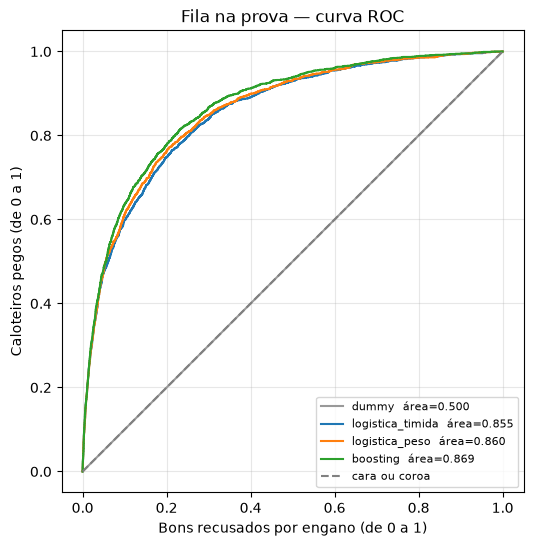

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
cores = {
    "dummy": "0.6",
    "logistica_timida": "C0",
    "logistica_peso": "C1",
    "boosting": "C2",
}

print("Área da fila na PROVA (não usa corte):")
for nome in alunos:
    y = y_test
    p = notas[nome]["prova"]
    fpr, tpr, _ = roc_curve(y, p)
    auc = roc_auc_score(y, p)
    ax.plot(fpr, tpr, color=cores[nome], label=f"{nome}  área={auc:.3f}")
    print(f"  {nome:20s}  fila={auc:.3f}  gini={2*auc-1:.3f}")

ax.plot([0, 1], [0, 1], ls="--", color="0.5", label="cara ou coroa")
ax.set_xlabel("Bons recusados por engano (de 0 a 1)")
ax.set_ylabel("Caloteiros pegos (de 0 a 1)")
ax.set_title("Fila na prova — curva ROC")
ax.legend(loc="lower right", fontsize=8)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.show()


### Como ler o gráfico ROC

1. O dummy **é** a diagonal (área 0,50). Se alguém empatar, o código está errado.
2. Os três alunos de verdade sobem juntos, longe da diagonal. Áreas ~0,86–0,87 — **já passam o 0,80 do 01**. O 04 não mentiu.
3. O boosting fica um fio acima. A logística tímida quase cola na de peso: o peso muda a **linha**, não a fila.
4. Este desenho **ainda não escolhe** aprovar/negar. Cada ponto da curva é *um* corte possível.


---
# 4. A outra curva: quando apontamos, acertamos?


A ROC trata bem e caloteiro com a mesma importância no desenho. Aqui só ~7% são calote. A curva precisão–recall pergunta:

- Eixo **Y**: quando eu aponto, em quantos % era calote mesmo?
- Eixo **X**: dos caloteiros, quantos eu já peguei?

O dummy é uma reta na altura de **6,7%** (a taxa da prova). Qualquer aluno útil fica **acima**.


Topo da fila na PROVA (área desta curva):
  logistica_timida      0.377
  logistica_peso        0.381
  boosting              0.395


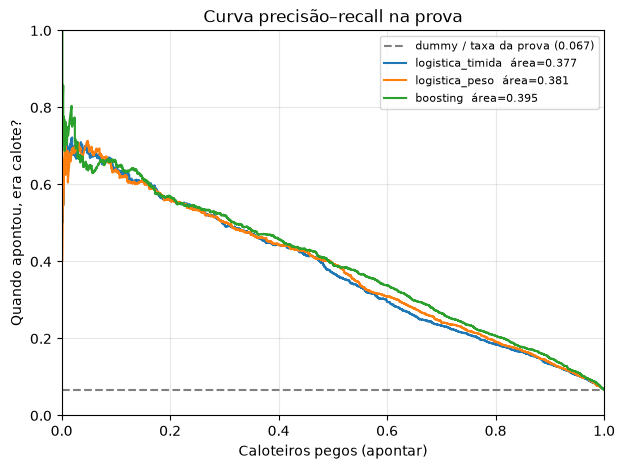

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
base = float(y_test.mean())
ax.axhline(base, ls="--", color="0.5", label=f"dummy / taxa da prova ({base:.3f})")

print("Topo da fila na PROVA (área desta curva):")
for nome in ["logistica_timida", "logistica_peso", "boosting"]:
    p = notas[nome]["prova"]
    prec, rec, _ = precision_recall_curve(y_test, p)
    ap = average_precision_score(y_test, p)
    ax.plot(rec, prec, color=cores[nome], label=f"{nome}  área={ap:.3f}")
    print(f"  {nome:20s}  {ap:.3f}")

ax.set_xlabel("Caloteiros pegos (apontar)")
ax.set_ylabel("Quando apontou, era calote?")
ax.set_title("Curva precisão–recall na prova")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
plt.show()


### Como ler a curva precisão–recall

Boosting ~0,39, logísticas ~0,38, dummy 0,067. O topo da fila é ~6× o acaso — o aluno *sabe* quem pôr na frente.

O preço de apontar **muitos** caloteiros (andar para a direita) é apontar também mais gente boa (a curva desce). É o trade-off do 01 em desenho: “melhor perder negócio do que tomar calote”.


---
# 5. KS — a língua do banco


## O que é o KS, sem o nome assustador

Ande da nota **mais alta** para a mais baixa. Em cada passo anote:

- “já passei por quantos % dos **caloteiros**?”
- “já passei por quantos % dos **bons**?”

O **KS** é o maior vão entre essas duas linhas. Se em algum ponto você já pegou 70% dos caloteiros e só 15% dos bons, o vão é 55%.

| KS | O que o 01 / o mercado lê |
|---|---|
| < 20% | Fraco |
| 20–40% | Regular a bom |
| **> 30%** | O alvo deste projeto |
| > 50% | Muito forte (crédito raramente chega nisso com dados públicos) |

KS 0 = as duas turmas se misturam (dummy). KS 1 = separação perfeita.


KS na prova (alvo do 01: > 0,30):
  dummy                 KS=0.000  (dummy: não há linha — todo mundo empatado)
  logistica_timida      KS=0.552  (vão máximo perto da nota 0.067)
  logistica_peso        KS=0.566  (vão máximo perto da nota 0.484)
  boosting              KS=0.583  (vão máximo perto da nota 0.456)


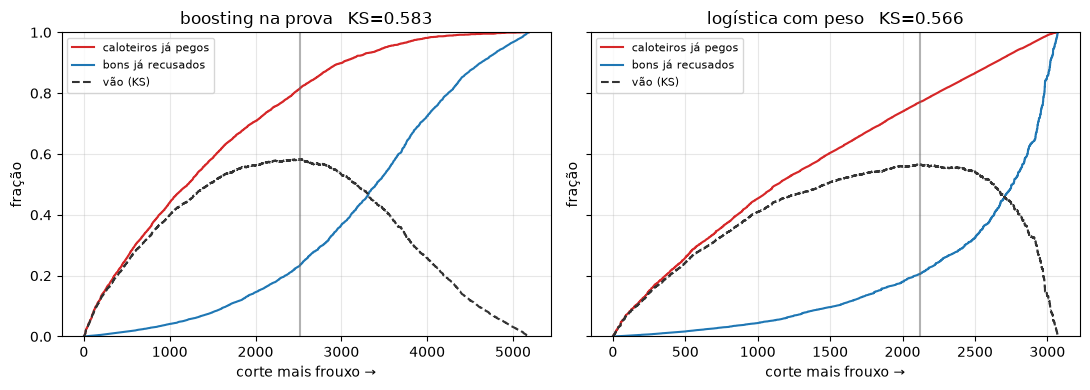

In [6]:
print("KS na prova (alvo do 01: > 0,30):")
for nome in alunos:
    ks, corte_ks = ks_vao(y_test, notas[nome]["prova"])
    extra = "(dummy: não há linha — todo mundo empatado)" if not np.isfinite(corte_ks) else f"(vão máximo perto da nota {corte_ks:.3f})"
    print(f"  {nome:20s}  KS={ks:.3f}  {extra}")


def desenha_ks(ax, y, nota, titulo):
    fpr, tpr, cortes = roc_curve(y, nota)
    vao = tpr - fpr
    i = int(np.argmax(vao))
    # Cortes podem ter inf no dummy — o eixo usa o índice.
    ax.plot(tpr, label="caloteiros já pegos", color="C3")
    ax.plot(fpr, label="bons já recusados", color="C0")
    ax.plot(vao, label="vão (KS)", color="0.2", ls="--")
    ax.axvline(i, color="0.4", alpha=0.5)
    ax.set_title(f"{titulo}   KS={vao[i]:.3f}")
    ax.set_xlabel("corte mais frouxo →")
    ax.set_ylabel("fração")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)


fig, eixos = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
desenha_ks(eixos[0], y_test, notas["boosting"]["prova"], "boosting na prova")
desenha_ks(eixos[1], y_test, notas["logistica_peso"]["prova"], "logística com peso")
plt.tight_layout()
plt.show()


### Como ler o KS (desta execução)

Boosting na prova: **KS ≈ 0,58** (58%). Logística com peso: **≈ 0,57**. Os dois **passam folgado** o 30% do 01.

O traço vertical é onde o vão é máximo — *não* é automaticamente a linha de crédito. É só o ponto em que as duas turmas mais se separam. A linha de crédito entra na seção 7, com o custo 20×.


---
# 6. O aluno decorou a prova? (treino vs prova)


Se a fila no **treino** for muito maior que na **prova**, ele decorou as 119.999 fichas. Um fio de diferença é normal. Um abismo (0,99 vs 0,70) é problema.


In [7]:
linhas = []
for nome in ["logistica_timida", "logistica_peso", "boosting"]:
    for lado, y, p in (
        ("treino", y_train, notas[nome]["treino"]),
        ("prova", y_test, notas[nome]["prova"]),
    ):
        m = metricas_fila(y, p)
        m["aluno"] = nome
        m["lado"] = lado
        linhas.append(m)

quadro = pd.DataFrame(linhas).set_index(["aluno", "lado"])
print(quadro.round(3).to_string())
print()
print("Diferença (treino − prova) da fila:")
for nome in ["logistica_timida", "logistica_peso", "boosting"]:
    d = quadro.loc[(nome, "treino"), "fila"] - quadro.loc[(nome, "prova"), "fila"]
    print(f"  {nome:20s}  {d:+.3f}")


                          fila   gini  topo_da_fila     ks
aluno            lado                                     
logistica_timida treino  0.849  0.698         0.374  0.539
                 prova   0.855  0.710         0.377  0.552
logistica_peso   treino  0.854  0.708         0.379  0.550
                 prova   0.860  0.720         0.381  0.566
boosting         treino  0.880  0.760         0.429  0.601
                 prova   0.869  0.739         0.395  0.583

Diferença (treino − prova) da fila:
  logistica_timida      -0.006
  logistica_peso        -0.006
  boosting              +0.011


### Como ler o quadro treino vs prova

Nesta execução o boosting tem fila 0,880 no treino e **0,869** na prova (diferença +0,011). A logística quase **empata** ou até fica um fio *melhor* na prova (sorte de amostra, não cola).

Não há abismo. O aluno generalizou. O 03 (split + régua só no treino) e o 04 (simulado interno) fizeram o trabalho.


---
# 7. Riscando a linha (a decisão do banco)


## 7.1 A conta do 01, em dinheiro de brinquedo

Cada **caloteiro aprovado** (FN) custa **20**.  
Cada **bom recusado** (FP) custa **1**.

Na prova há **2.005** caloteiros e **27.995** bons.

- Dummy (aprova todo mundo): custo \(= 2005 \times 20 = 40.100\).
- Recusar todo mundo: custo \(= 27995 \times 1 = 27.995\) — mais barato que o dummy, mas o banco quebra sem cliente. Não é política.

Queremos a linha que **minimiza** \(20\times\text{FN} + 1\times\text{FP}\) **no treino**. Depois medimos essa linha **uma vez** na prova.

Por que não 50%? A logística tímida dá nota ~7%. O 50% está no lugar errado da turma. O 01 pediu linha **baixa** (conservadora) para apontar caloteiro.


## 7.2 Busca da linha — **só no treino**


Linha de menor custo no TREINO (boosting): 0.43
custo                 53333.000
fn                     1263.000
fp                    28073.000
tp                     6758.000
tn                    83905.000
apontou_caloteiro         0.843
quando_apontou_era        0.194

Amostra da tabela do treino (para ver o vale):
       custo    fn     fp    tp      tn  apontou_caloteiro  quando_apontou_era
corte                                                                         
0.20   63902   385  56202  7636   55776              0.952               0.120
0.35   54019   942  35179  7079   76799              0.883               0.168
0.43   53333  1263  28073  6758   83905              0.843               0.194
0.50   54462  1612  22222  6409   89756              0.799               0.224
0.65   66104  2733  11444  5288  100534              0.659               0.316


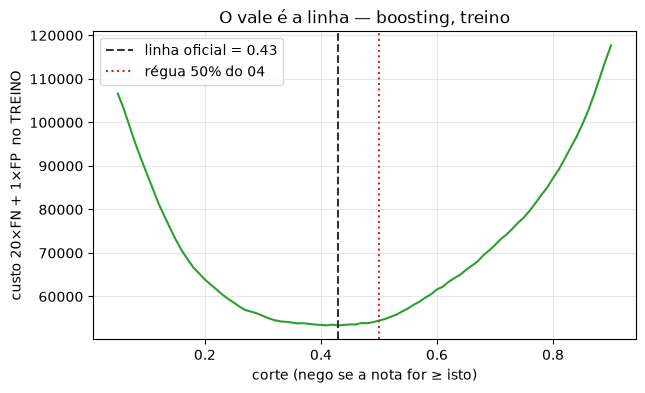

In [8]:
def busca_linha(y, nota, cortes=None):
    """Varre cortes e devolve uma tabela. O vencedor = menor custo."""
    if cortes is None:
        cortes = np.round(np.linspace(0.05, 0.90, 86), 2)
    rows = []
    for c in cortes:
        pred = (nota >= c).astype(int)
        d = custo_linha(y, pred)
        d["corte"] = float(c)
        rows.append(d)
    tab = pd.DataFrame(rows).set_index("corte")
    return tab


# Oficial: boosting, linha escolhida no TREINO.
tab_tr = busca_linha(y_train, notas["boosting"]["treino"])
corte_oficial = float(tab_tr["custo"].idxmin())

print("Linha de menor custo no TREINO (boosting):", corte_oficial)
print(tab_tr.loc[corte_oficial].round(3).to_string())
print()
print("Amostra da tabela do treino (para ver o vale):")
print(tab_tr.loc[[0.20, 0.35, 0.43, 0.50, 0.65]].round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tab_tr.index, tab_tr["custo"], color="C2")
ax.axvline(corte_oficial, ls="--", color="0.2", label=f"linha oficial = {corte_oficial}")
ax.axvline(0.50, ls=":", color="C3", label="régua 50% do 04")
ax.set_xlabel("corte (nego se a nota for ≥ isto)")
ax.set_ylabel("custo 20×FN + 1×FP  no TREINO")
ax.set_title("O vale é a linha — boosting, treino")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


### Como ler a busca

O vale desta execução está em **0,43** — um pouco abaixo de 50%. Faz sentido: o 01 pediu conservador, mas o boosting *já* tinha notas altas (peso extra). Não precisou ir a 0,10.

Compare 0,43 com 0,50 na tabelinha: no treino o 0,43 aponta **mais** caloteiro e custa **menos**. O 50% do 04 era um poste improvisado; o vale é a política.


## 7.3 Um tiro na prova — a nota oficial


In [9]:
def imprime_lado(titulo, y, nota, corte):
    pred = (nota >= corte).astype(int)
    d = custo_linha(y, pred)
    print(titulo)
    print(f"  corte {corte:.2f}  custo {d['custo']:,}  "
          f"FN {d['fn']}  FP {d['fp']}  "
          f"apontou {d['apontou_caloteiro']:.1%}  "
          f"quando apontou era {d['quando_apontou_era']:.1%}")
    return d


print("=== BOOSTING ===")
d_oficial = imprime_lado("PROVA na linha oficial (escolhida no treino):",
                         y_test, notas["boosting"]["prova"], corte_oficial)
d_50 = imprime_lado("PROVA na régua 50% (só para comparar):",
                    y_test, notas["boosting"]["prova"], 0.50)
d_dummy = imprime_lado("PROVA dummy (aprova todo mundo):",
                       y_test, notas["dummy"]["prova"], 0.50)

print()
print("=== LOGÍSTICA COM PESO (linha dela, também no TREINO) ===")
tab_log = busca_linha(y_train, notas["logistica_peso"]["treino"])
corte_log = float(tab_log["custo"].idxmin())
d_log = imprime_lado(f"PROVA logística, linha {corte_log:.2f}:",
                     y_test, notas["logistica_peso"]["prova"], corte_log)


=== BOOSTING ===
PROVA na linha oficial (escolhida no treino):
  corte 0.43  custo 13,980  FN 347  FP 7040  apontou 82.7%  quando apontou era 19.1%
PROVA na régua 50% (só para comparar):
  corte 0.50  custo 14,476  FN 445  FP 5576  apontou 77.8%  quando apontou era 21.9%
PROVA dummy (aprova todo mundo):
  corte 0.50  custo 40,100  FN 2005  FP 0  apontou 0.0%  quando apontou era 0.0%

=== LOGÍSTICA COM PESO (linha dela, também no TREINO) ===
PROVA logística, linha 0.35:
  corte 0.35  custo 14,450  FN 267  FP 9110  apontou 86.7%  quando apontou era 16.0%


### Como ler o tiro oficial (desta execução)

| Política na prova (30.000 fichas, 2.005 caloteiros) | Custo | FN | FP | Apontou caloteiro |
|---|---|---|---|---|
| Dummy (aprova todos) | 40.100 | 2.005 | 0 | 0% |
| Boosting no **50%** | 14.476 | 445 | 5.576 | 77,8% |
| **Boosting na linha 0,43** | **13.980** | **347** | 7.040 | **82,7%** |
| Logística com peso na linha 0,35 | 14.450 | 267 | 9.110 | 86,7% |

A linha oficial **passa o 75%** do 01 (82,7%) e custa menos que o 50%. A logística aponta ainda mais caloteiro — e recusa mais gente boa. O boosting é o meio-termo: menos custo total.

FN caiu de 445 para 347: **98 caloteiros a menos** aprovados, ao preço de recusar ~1.500 bons a mais. Com a conta 20×1, o negócio aceita.


## 7.4 A matriz 2×2 — quatro caixinhas


```
                    o modelo APONTOU          o modelo LIBEROU
de verdade calote   TP  (peguei)              FN  (prejuízo ×20)
de verdade bom      FP  (negócio perdido ×1)  TN  (cliente feliz)
```


In [10]:
def mostra_matriz(y, nota, corte, titulo):
    pred = (nota >= corte).astype(int)
    mat = confusion_matrix(y, pred, labels=[0, 1])
    # sklearn: linhas = verdade, colunas = predito. [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = mat.ravel()
    print(titulo)
    print(f"                apontou          liberou")
    print(f"  caloteiro     TP={tp:5d}         FN={fn:5d}")
    print(f"  bom           FP={fp:5d}         TN={tn:5d}")
    print()


mostra_matriz(y_test, notas["boosting"]["prova"], corte_oficial,
              f"Boosting na prova, corte {corte_oficial:.2f}  (oficial)")
mostra_matriz(y_test, notas["boosting"]["prova"], 0.50,
              "Boosting na prova, corte 0,50  (régua do 04)")


Boosting na prova, corte 0.43  (oficial)
                apontou          liberou
  caloteiro     TP= 1658         FN=  347
  bom           FP= 7040         TN=20955

Boosting na prova, corte 0,50  (régua do 04)
                apontou          liberou
  caloteiro     TP= 1560         FN=  445
  bom           FP= 5576         TN=22419



### Como ler as caixinhas

Na linha oficial o **FN** (prejuízo) é menor e o **FP** (negócio perdido) é maior do que no 50%. É exatamente o conservador do 01.

Não some as quatro e chame de “acertos”. TN é enorme (~20 mil) e afoga a conversa — a mesma armadilha dos 93%.


---
# 8. As notas são porcentagens de verdade? (calibração)


Se o aluno diz “20%” para mil pessoas, cerca de 200 deveriam calotear. Quando isso acontece, a nota está **calibrada**.

Peso extra **empurra** as notas para cima de propósito. A fila continua boa; o número “0,60” deixa de significar “60% de chance”. Por isso a **linha** existe: ela não precisa que 0,43 queira dizer 43%. Precisa só que quem está acima de 0,43 seja, em média, pior do que quem está abaixo.


Brier na prova (menor = notas mais 'honestas'; dummy ≈ 0,067):
  logistica_timida      0.051
  logistica_peso        0.146
  boosting              0.140


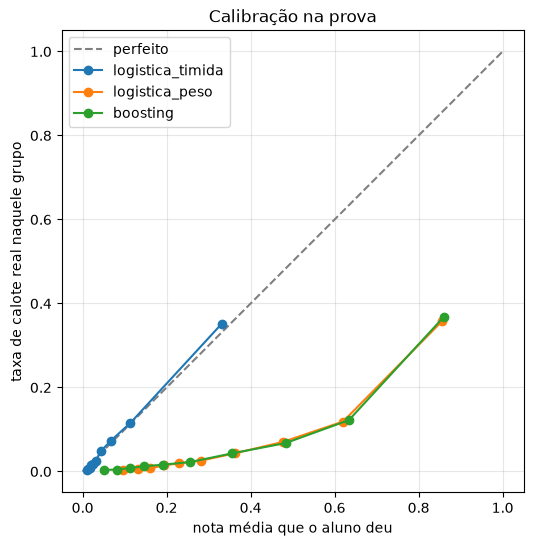

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], ls="--", color="0.5", label="perfeito")

print("Brier na prova (menor = notas mais 'honestas'; dummy ≈ 0,067):")
for nome in ["logistica_timida", "logistica_peso", "boosting"]:
    p = notas[nome]["prova"]
    frac, media = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    ax.plot(media, frac, marker="o", label=nome)
    print(f"  {nome:20s}  {brier_score_loss(y_test, p):.3f}")

ax.set_xlabel("nota média que o aluno deu")
ax.set_ylabel("taxa de calote real naquele grupo")
ax.set_title("Calibração na prova")
ax.legend()
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.show()


### Como ler a calibração

A logística **tímida** cola mais na diagonal (Brier ~0,05) — as notas dela *parecem* porcentagem. Boosting e logística com peso ficam **acima** da nota (Brier ~0,14): dizem 60% e a turma caloteia menos que 60%. É o peso extra.

Não jogue o campeão fora por isso. A linha 0,43 já absorveu o deslocamento. Se um dia o banco quiser “esta nota = PD real”, aí sim entra uma calibração extra (fora deste caderno).


---
# 9. Os dois alunos na mesa do banco


O 04 pediu para levar o campeão **e** a logística com peso. Comparação honesta: cada um com a **própria** linha (buscada no treino), medida na prova.


In [12]:
resumo = pd.DataFrame(
    {
        "boosting": {
            "fila_prova": metricas_fila(y_test, notas["boosting"]["prova"])["fila"],
            "ks_prova": metricas_fila(y_test, notas["boosting"]["prova"])["ks"],
            "linha": corte_oficial,
            **{k: d_oficial[k] for k in ("custo", "fn", "fp", "apontou_caloteiro")},
        },
        "logistica_peso": {
            "fila_prova": metricas_fila(y_test, notas["logistica_peso"]["prova"])["fila"],
            "ks_prova": metricas_fila(y_test, notas["logistica_peso"]["prova"])["ks"],
            "linha": corte_log,
            **{k: d_log[k] for k in ("custo", "fn", "fp", "apontou_caloteiro")},
        },
    }
).T

print(resumo.round(3).to_string())
print()
print("Quem eu levo como motor de nota : boosting (melhor fila, menor custo)")
print("Quem eu levo para explicar o 'não': logística com peso (cartão e atraso 90+)")


                fila_prova  ks_prova  linha    custo     fn      fp  apontou_caloteiro
boosting             0.869     0.583   0.43  13980.0  347.0  7040.0              0.827
logistica_peso       0.860     0.566   0.35  14450.0  267.0  9110.0              0.867

Quem eu levo como motor de nota : boosting (melhor fila, menor custo)
Quem eu levo para explicar o 'não': logística com peso (cartão e atraso 90+)


### Como ler a mesa

Boosting ganha **fila**, **KS** e **custo**. Logística aponta um pouco mais de caloteiro e recusa mais gente boa.

Para o projeto: **motor = boosting**, linha **0,43**. A logística fica na gaveta da auditoria — o 02 já tinha dito que cartão e atraso 90+ mandam, e os pesos do 04 bateram com isso.


---
# 10. O checklist do caderno 01


In [13]:
fila = metricas_fila(y_test, notas["boosting"]["prova"])
apontou = d_oficial["apontou_caloteiro"]
ks = fila["ks"]

checks = [
    ("fila (AUC) > 0,80", fila["fila"] > 0.80, f"{fila['fila']:.3f}"),
    ("KS > 30%", ks > 0.30, f"{ks:.1%}"),
    ("apontar caloteiro > 75%  (na linha oficial)", apontou > 0.75, f"{apontou:.1%}"),
]

print("Política oficial: boosting, corte", corte_oficial, "escolhido no TREINO.")
print()
for nome, ok, num in checks:
    marca = "SIM" if ok else "NÃO"
    print(f"  [{marca}]  {nome:50s}  {num}")

print()
print("Explicável para auditoria: SIM — logística com peso (caderno 04, seção dos pesos).")
print("Pipeline CRISP-DM completo até a decisão: SIM (01→05).")


Política oficial: boosting, corte 0.43 escolhido no TREINO.

  [SIM]  fila (AUC) > 0,80                                   0.869
  [SIM]  KS > 30%                                            58.3%
  [SIM]  apontar caloteiro > 75%  (na linha oficial)         82.7%

Explicável para auditoria: SIM — logística com peso (caderno 04, seção dos pesos).
Pipeline CRISP-DM completo até a decisão: SIM (01→05).


### Como ler o checklist

Nesta execução os três números **passam**:

- Fila 0,869 > 0,80
- KS 58% > 30%
- Apontou 82,7% > 75%

O 50% do 04 já tinha 77,8% no boosting. A linha 0,43 **não foi necessária** para “passar de 75%” — foi necessária para **baratear o prejuízo** (13.980 vs 14.476) e para o ritual: a meta do 01 vive *numa política*, não num poste improvisado.


---
# 11. Texto para alguém que não é da área


> Treinamos um modelo com 120 mil fichas antigas para estimar o risco de atraso grave em 2 anos.  
> Ele **ordena** bem: se eu pegar um caloteiro e um bom pagador, em ~87% das vezes o caloteiro fica na frente (o acaso faria 50%; o alvo era 80%).  
> No jargão do banco, o KS deu **58%** (o alvo era 30%).  
> A regra de recusa é: se a nota for **0,43 ou mais**, não aprovamos. Com isso pegamos **cerca de 83 em cada 100** caloteiros da prova. Recusamos também gente boa — o 01 aceitou esse preço porque um calote custa ~20 vezes uma venda perdida.  
> Se um auditor perguntar “por que esta pessoa?”, usamos a conta de pesos: cartão muito usado e atraso de 90+ dias empurram a nota para cima; idade e renda empurram para baixo. Isso bate com o que vimos nos dados crus.

**Limitações (fale na reunião, não esconda):**

1. A linha foi escolhida no treino e medida **uma** vez na prova. Em produção ela precisa ser revisitada (a turma muda).
2. As notas do boosting **não** são PD calibrada. Não diga ao cliente “você tem 43% de chance”. Diga “ficou acima da nossa linha”.
3. Renda em branco (~20%) foi preenchida com 5.400 e ganhou bandeirinha — o 02 mostrou que esse grupo caloteia *menos*, não mais.
4. Não medimos justiça entre grupos (idade pode ter proteção legal). O 06 / um estudo de fairness fica em aberto.
5. O custo 20×1 é uma **régua de aprendizado**, não a planilha real do banco. Se FN custar 8× ou 50×, a linha anda.


---
# 12. Guardar a política


In [14]:
politica = {
    "motor": "hist_gb",
    "explicavel": "logreg_balanced",
    "corte": corte_oficial,
    "corte_foi_escolhido_em": "treino",
    "custo_fn": C_FN,
    "custo_fp": C_FP,
    "prova": {
        "n": int(len(y_test)),
        "caloteiros": int(y_test.sum()),
        "fila": float(fila["fila"]),
        "gini": float(fila["gini"]),
        "ks": float(ks),
        "apontou_caloteiro": float(apontou),
        "custo": int(d_oficial["custo"]),
        "fn": int(d_oficial["fn"]),
        "fp": int(d_oficial["fp"]),
        "custo_no_corte_50": int(d_50["custo"]),
        "custo_dummy": int(d_dummy["custo"]),
    },
    "checklist_01": {
        "auc_acima_0_80": bool(fila["fila"] > 0.80),
        "ks_acima_0_30": bool(ks > 0.30),
        "recall_acima_0_75": bool(apontou > 0.75),
    },
    "notas": (
        "Linha escolhida minimizando 20*FN+1*FP no treino. "
        "Métricas oficiais são as da prova nesse corte. "
        "O 50% do caderno 04 não é a política."
    ),
}
caminho = MODELS / "politica_fase5.json"
caminho.write_text(json.dumps(politica, ensure_ascii=False, indent=2))
print("escrevi", caminho)
print(json.dumps(politica, ensure_ascii=False, indent=2))


escrevi /Users/vinicius/Documents/workspace/credit_risk_scoring/models/politica_fase5.json
{
  "motor": "hist_gb",
  "explicavel": "logreg_balanced",
  "corte": 0.43,
  "corte_foi_escolhido_em": "treino",
  "custo_fn": 20,
  "custo_fp": 1,
  "prova": {
    "n": 30000,
    "caloteiros": 2005,
    "fila": 0.8694098830437748,
    "gini": 0.7388197660875495,
    "ks": 0.5827081697435283,
    "apontou_caloteiro": 0.8269326683291771,
    "custo": 13980,
    "fn": 347,
    "fp": 7040,
    "custo_no_corte_50": 14476,
    "custo_dummy": 40100
  },
  "checklist_01": {
    "auc_acima_0_80": true,
    "ks_acima_0_30": true,
    "recall_acima_0_75": true
  },
  "notas": "Linha escolhida minimizando 20*FN+1*FP no treino. Métricas oficiais são as da prova nesse corte. O 50% do caderno 04 não é a política."
}


## Se você souber explicar isto, aprendeu

1. **Por que a fila do 04 já valia e mesmo assim existia o 05?**  
   Porque fila não escolhe *quem* aprova. O banco precisa de uma linha e de um KS.

2. **Por que a linha nasce no treino, não na prova?**  
   Se o 0,43 for o que ficou bonito na prova, a prova deixou de ser prova. O 01 viraria recado.

3. **Por que 50% não é a meta de 75% do 01?**  
   75% é “na política, pegamos 3 em cada 4 caloteiros”. 50% era um poste para comparar alunos. Podem coincidir (aqui quase coincidiram). Não são a mesma pergunta.

4. **Por que KS 58% e fila 0,87 contam a mesma história?**  
   Os dois medem separação. KS é um *vão máximo*; a fila é a *área* de todos os vãos. Banco fala KS; paper fala AUC.

5. **Por que a logística tímida tem KS alto e aponta 17% no 50%?**  
   As notas dela vivem perto de 7%. A separação existe (KS ~55%); o poste 50% está longe da turma. A linha dela no vale (~0,05) aponta ~82% — a mesma lição do 01: **abaixe** a linha.

6. **O modelo “responde à pergunta do 01”?**  
   Sim: estima risco de atraso grave em 2 anos, ordena acima do alvo, e com a linha 0,43 pega mais de 75% dos caloteiros, aceitando recusar gente boa.

### Extra que este caderno não fez (de propósito)

Lift/gain chart, SHAP numa recusa, fairness por idade, recalibrar a nota. O [06](06_deployment_notes.ipynb) é o lugar de perguntar “e agora, em produção?”.
